reference: https://github.com/PSAM-5020-2025F-A/Project-OpenCV/blob/main/opencv-tests.ipynb

In [14]:
import cv2
import numpy as np
from pathlib import Path
from PIL import Image as PImage
# import matplotlib.pyplot as plt

In [15]:
# helper functions to convert between PIL and OpenCV image types
def tocv(pil):
  return np.array(pil)

def topil(cv):
  return PImage.fromarray(cv)

# Testing on single image

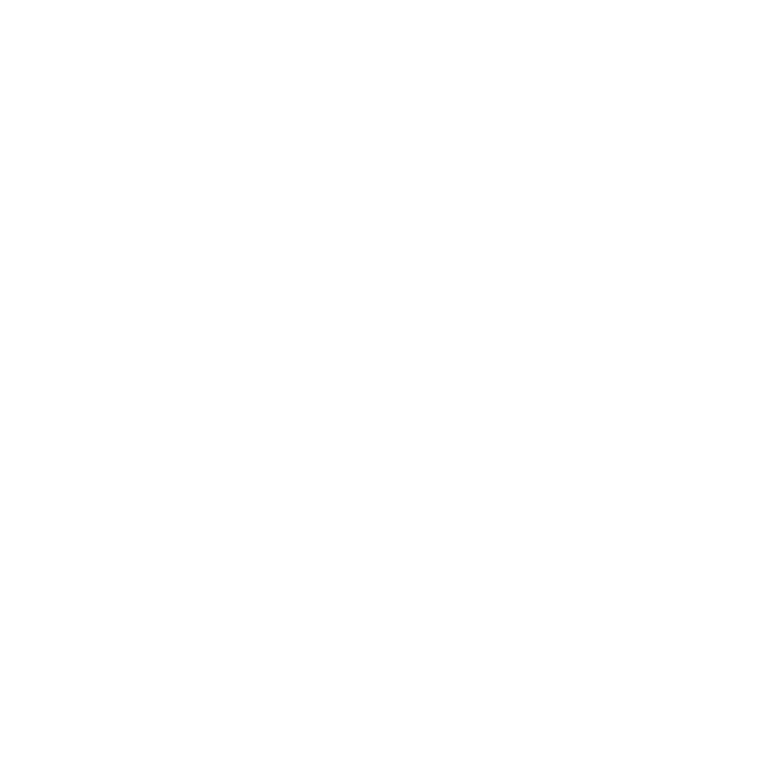

In [16]:
# open image from test_images
object_ids = ["185901", "203377", "192803", "45529", "188908", "204512", "449904"]

test_images_dir = Path("../pipeline/test_images").resolve()
mask_path = test_images_dir / f"{object_ids[0]}_mask_standardized.png"
img = PImage.open(mask_path).convert("RGBA")

display(img)

In [17]:
rgba = np.array(img, dtype=np.uint8)
alpha = rgba[:, :, 3]  # best channel for your pipeline masks

In [18]:
# binary options:
binary_options = [1, 32]
_, binary = cv2.threshold(alpha, binary_options[1], 255, cv2.THRESH_BINARY)

In [19]:
# methods:
method_options = [cv2.CHAIN_APPROX_NONE, cv2.CHAIN_APPROX_SIMPLE]
contours, hierarchy = cv2.findContours(image=binary, mode=cv2.RETR_CCOMP, method=method_options[1])

In [20]:
outer_contours = []
inner_contours = []
if hierarchy is not None:
  h = hierarchy[0]  # shape: (N, 4), [next, prev, first_child, parent]
  for i, cnt in enumerate(contours):
      parent = h[i][3]
      if parent == -1:
          outer_contours.append(cnt.reshape(-1, 2))  # outer boundary
      else:
          inner_contours.append(cnt.reshape(-1, 2))  # hole boundary
print("all:", len(contours), "outer:", len(outer_contours), "inner:", len(inner_contours))

all: 15 outer: 1 inner: 14


#### Draw B&W outline on black background

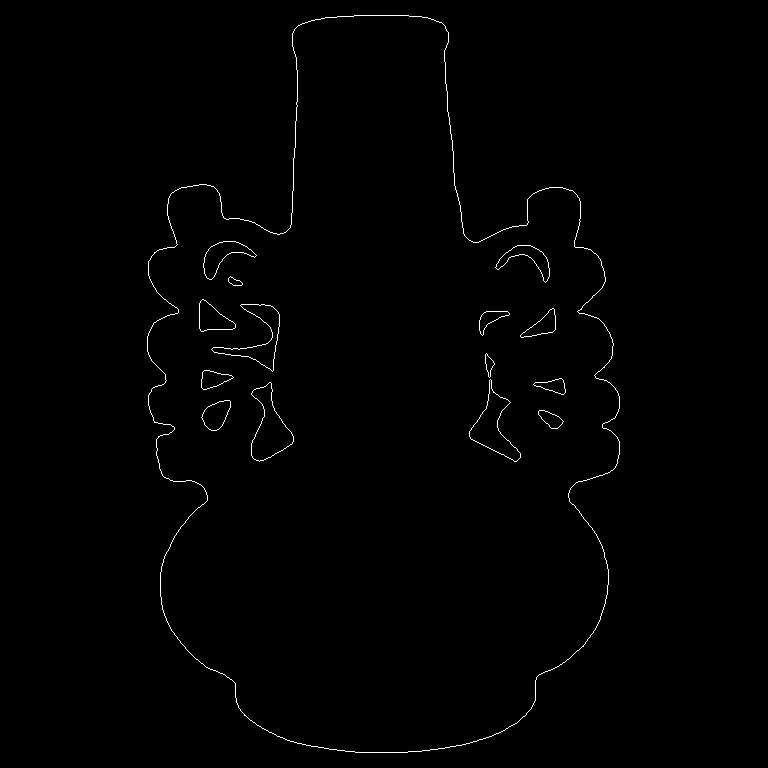

In [21]:
# Draw all detected contours in white on a black background
outline_black = np.zeros((binary.shape[0], binary.shape[1], 3), dtype=np.uint8)

if contours:
    cv2.drawContours(outline_black, contours, -1, (255, 255, 255), 1)

display(PImage.fromarray(cv2.cvtColor(outline_black, cv2.COLOR_BGR2RGB)))

# Test function in file

In [22]:
def draw_contours(contours, color=(255, 255, 255), thickness=1):
    # Draw all detected contours in white on a black background
    outline_black = np.zeros((binary.shape[0], binary.shape[1], 3), dtype=np.uint8)

    if contours:
        cv2.drawContours(outline_black, contours, -1, color, thickness)

    return PImage.fromarray(cv2.cvtColor(outline_black, cv2.COLOR_BGR2RGB))

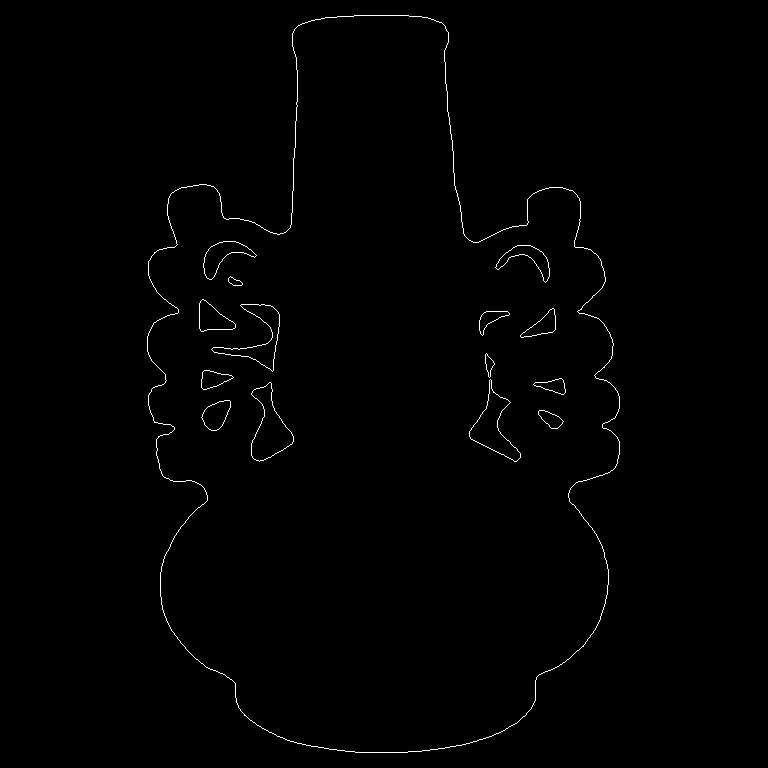

In [23]:
from extract_outline_2 import extract_outline_from_mask

contours, outer_contours, inner_contours = extract_outline_from_mask(object_id=object_ids[0])

draw_contours(contours)

# Test alpha values

In [24]:
alpha_values = [1, 8, 16, 24, 32, 40, 48, 64]

### outcome: 8 looks best

1 is too detailed and captures random dots, whereas 8 still captures max details without the noise

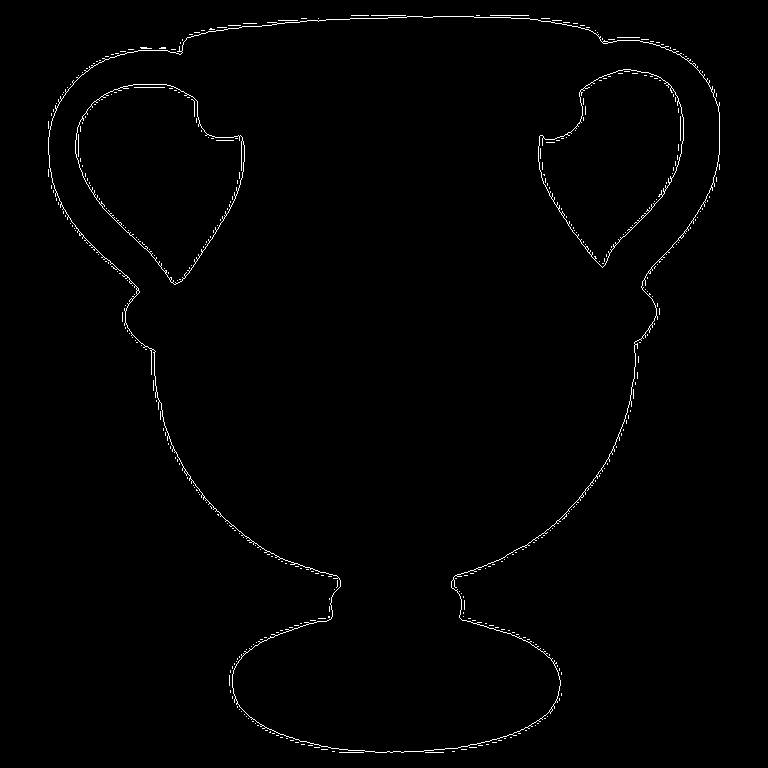

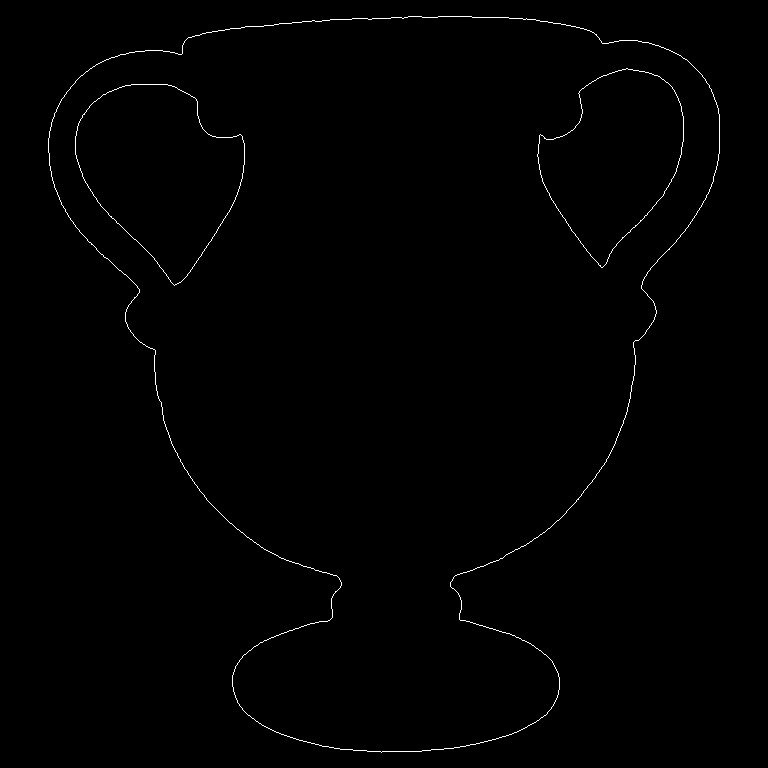

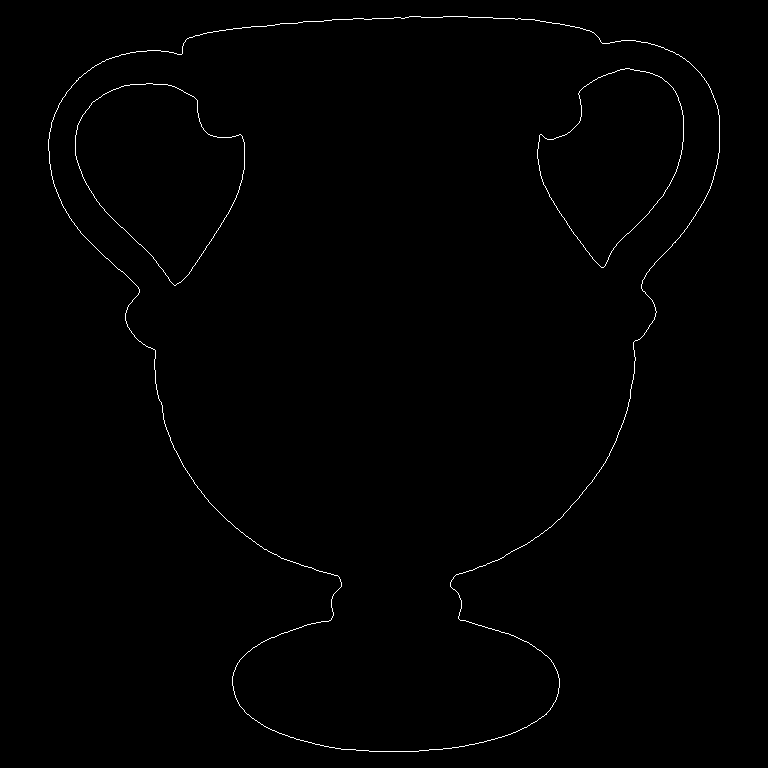

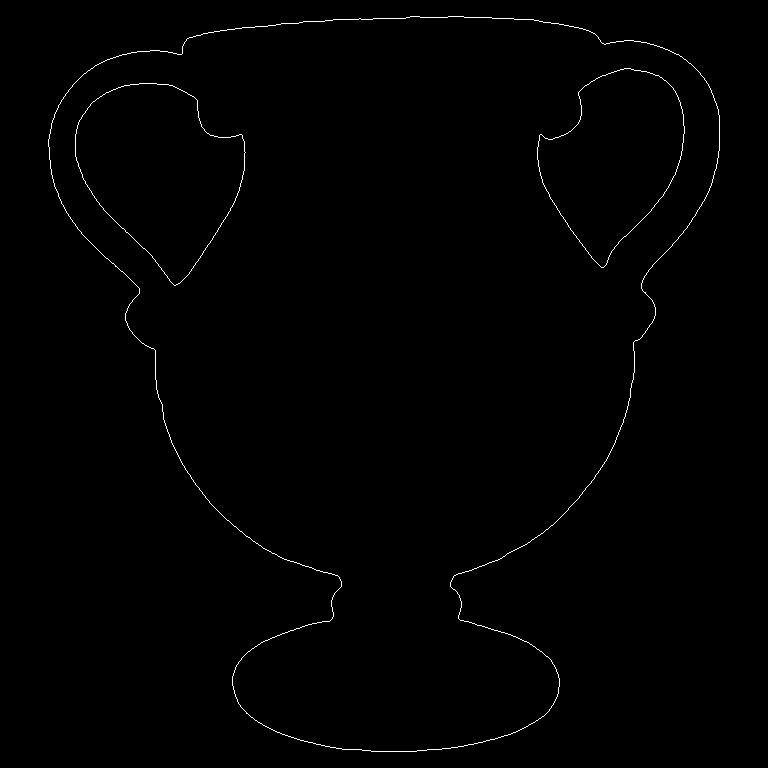

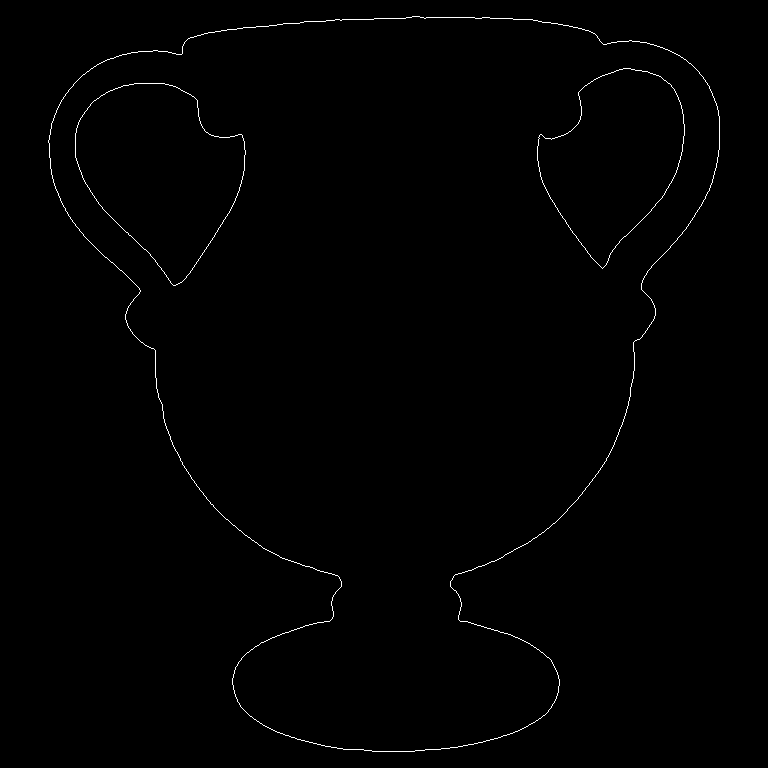

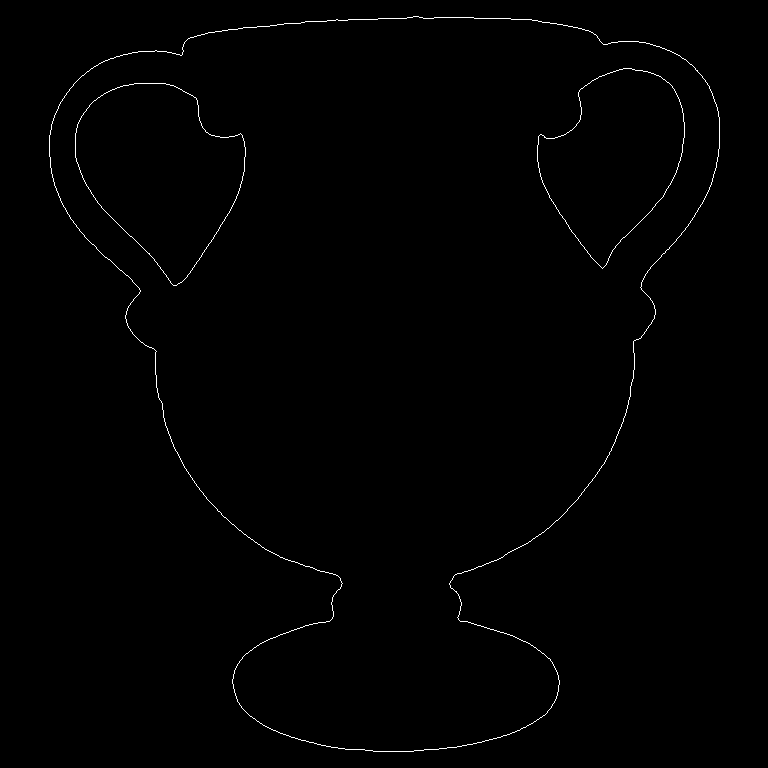

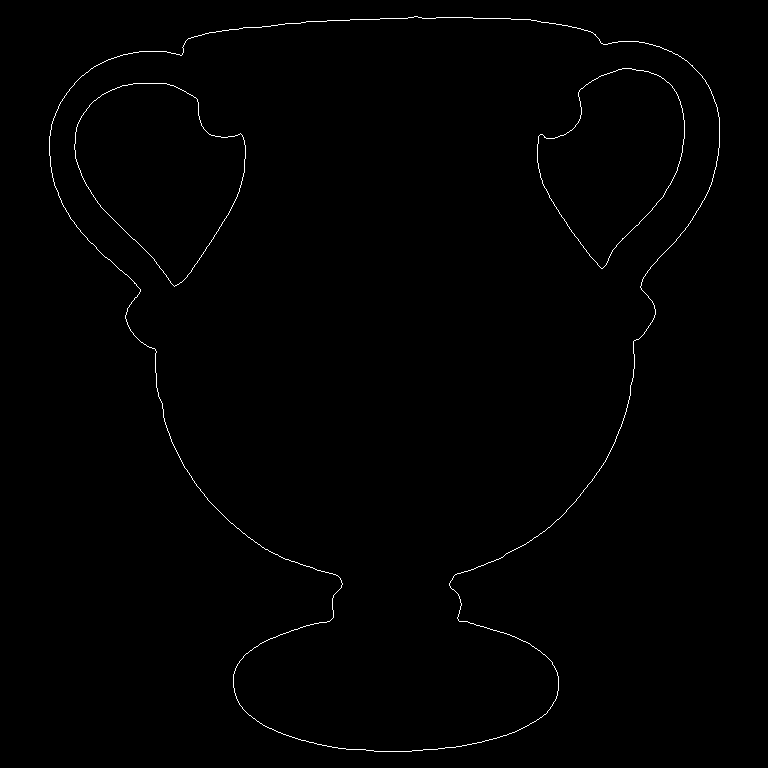

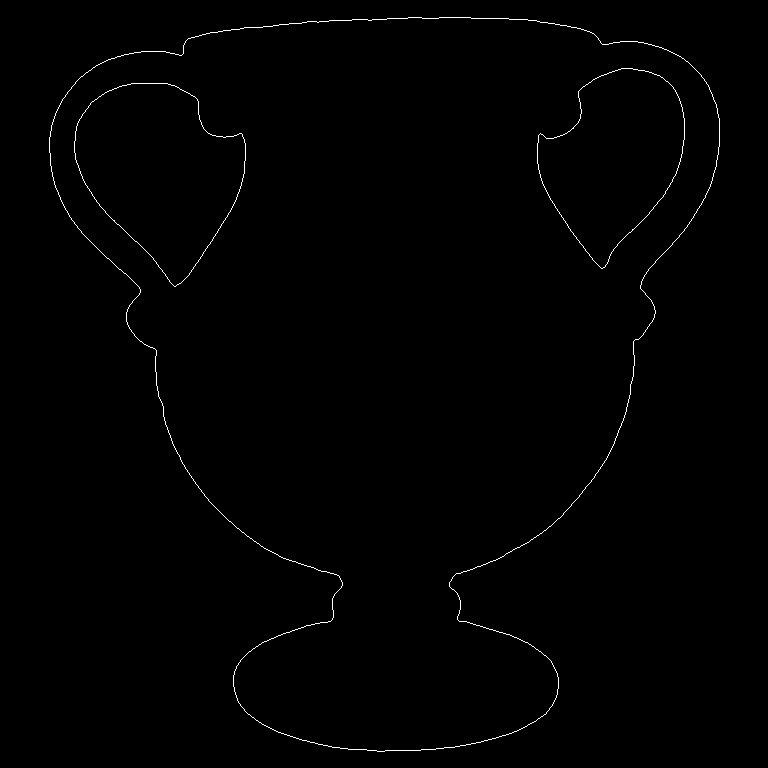

In [29]:
for val in alpha_values:
    contours, outer_contours, inner_contours = extract_outline_from_mask(object_id=object_ids[4], alpha_threshold=val)
    display(draw_contours(contours))